# Sentiment Analysis — Naive Bayes (SST)

### Join pipeline
```
datasetSentences.txt  -->  dictionary.txt  -->  sentiment_labels.txt
   (sentence text)     (text -> phrase_id)    (phrase_id -> score)
```

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.naive_bayes import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


## 2. Load All SST Files

All files are read from `stanfordSentimentTreebank/`.

In [2]:
BASE = 'stanfordSentimentTreebank'

# Sentence index -> sentence text
sentences = pd.read_csv(
    f'{BASE}/datasetSentences.txt',
    sep='\t', header=0,
    names=['sentence_index', 'sentence']
)

# Phrase text -> phrase_id  (the critical bridge file)
dictionary = pd.read_csv(
    f'{BASE}/dictionary.txt',
    sep='|', header=None,
    names=['phrase', 'phrase_id']
)

# phrase_id -> continuous sentiment score [0, 1]
labels = pd.read_csv(
    f'{BASE}/sentiment_labels.txt',
    sep='|', header=0,
    names=['phrase_id', 'sentiment_score']
)

# sentence_index -> split assignment (1=train, 2=test, 3=dev)
splits = pd.read_csv(
    f'{BASE}/datasetSplit.txt',
    sep=',', header=0,
    names=['sentence_index', 'split_set']
)

print(f'Sentences:  {len(sentences):,}')
print(f'Dictionary: {len(dictionary):,} phrases')
print(f'Labels:     {len(labels):,}')
print(f'Splits:     {len(splits):,}')

Sentences:  11,855
Dictionary: 239,232 phrases
Labels:     239,232
Splits:     11,855


## 3. Build the Join

```
sentences --[sentence text]--> dictionary --[phrase_id]--> labels
```

Normalise both sides to handle SST parser artifacts (e.g. `-LRB-`, extra spaces) before joining.

In [3]:
def normalise(text):
    """Normalise parser artifacts and whitespace."""
    text = str(text)
    text = text.replace('-LRB-', '(').replace('-RRB-', ')')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sentences['sentence_norm'] = sentences['sentence'].apply(normalise)
dictionary['phrase_norm']  = dictionary['phrase'].apply(normalise)

df = sentences.merge(
    dictionary[['phrase_norm', 'phrase_id']],
    left_on='sentence_norm', right_on='phrase_norm',
    how='inner'
)

df = df.merge(labels, on='phrase_id', how='inner')

df = df.merge(splits, on='sentence_index', how='inner')

print(f'Matched {len(df):,} of {len(sentences):,} sentences')
print(f'Unmatched: {len(sentences) - len(df):,} (parser artefacts with no dictionary entry)')
print()

print('Sample rows (verify labels make intuitive sense):')
print(df[['sentence', 'sentiment_score']].sample(8, random_state=1).to_string(index=False))

Matched 11,755 of 11,855 sentences
Unmatched: 100 (parser artefacts with no dictionary entry)

Sample rows (verify labels make intuitive sense):
                                                                                                                                                                            sentence  sentiment_score
                                                                                                               One of the very best movies ever made about the life of moviemaking .         0.847220
                                                                    It 's crap on a leash -- far too polite to scale the lunatic heights of Joe Dante 's similarly styled Gremlins .         0.041667
                                              A worthwhile documentary , whether you 're into rap or not , even if it may still leave you wanting more answers as the credits roll .         0.777780
                                                   There 's not

## 4. Map Scores to Classes & Inspect Distribution

Binary Class Distribution (full dataset):
label_binary
positive    6144
negative    5611
Name: count, dtype: int64



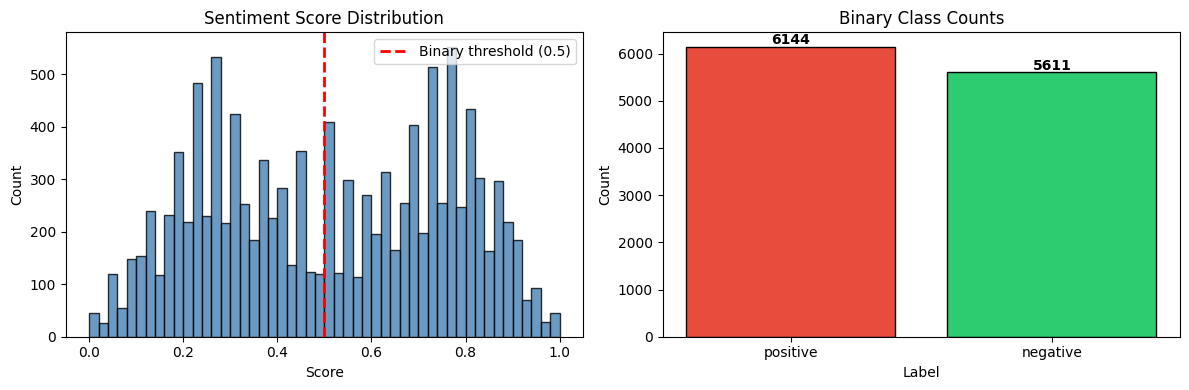

In [4]:
def score_to_label(score):
    if score <= 0.40:
        return 'negative'
    elif score <= 0.60:
        return 'neutral'
    else:
        return 'positive'

def score_to_binary_label(score):
    """Binary classification: exclude neutral, classify as negative or positive."""
    if score < 0.5:
        return 'negative'
    else:
        return 'positive'

df['label'] = df['sentiment_score'].apply(score_to_label)
df['label_binary'] = df['sentiment_score'].apply(score_to_binary_label)

print('Binary Class Distribution (full dataset):')
print(df['label_binary'].value_counts())
print()

# Visualize both distributions for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sentiment_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Binary threshold (0.5)')
axes[0].set_title('Sentiment Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

colors = ['#e74c3c', '#2ecc71']
counts = df['label_binary'].value_counts()
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[1].set_title('Binary Class Counts')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
for i, (label, v) in enumerate(zip(counts.index, counts.values)):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Train / Dev / Test Split

Official SST splits from `datasetSplit.txt`:
- Split 1 = train
- Split 2 = test
- Split 3 = dev

In [5]:
train_df = df[df['split_set'] == 1].copy()
dev_df   = df[df['split_set'] == 3].copy()
test_df  = df[df['split_set'] == 2].copy()

# Filter to binary classification (exclude neutral sentences)
train_df = train_df[train_df['label'] != 'neutral'].copy()
dev_df   = dev_df[dev_df['label'] != 'neutral'].copy()
test_df  = test_df[test_df['label'] != 'neutral'].copy()

print(f'Binary Train: {len(train_df):,}  |  Dev: {len(dev_df):,}  |  Test: {len(test_df):,}')
print()
print('Train binary class distribution:')
print(train_df['label'].value_counts())

Binary Train: 6,842  |  Dev: 866  |  Test: 1,817

Train binary class distribution:
label
positive    3583
negative    3259
Name: count, dtype: int64


## 6. Balance the Training Set

Neutral undersampled to match minority class size. Dev and test sets are unchanged.

In [6]:
tr_neg = train_df[train_df['label'] == 'negative']
tr_pos = train_df[train_df['label'] == 'positive']

minority_size = min(len(tr_neg), len(tr_pos))
tr_neg_balanced = resample(tr_neg, replace=False, n_samples=minority_size, random_state=42)
tr_pos_balanced = resample(tr_pos, replace=False, n_samples=minority_size, random_state=42)

train_balanced = pd.concat([tr_neg_balanced, tr_pos_balanced]).sample(frac=1, random_state=42)

print('Balanced training binary class distribution:')
print(train_balanced['label'].value_counts())

Balanced training binary class distribution:
label
positive    3259
negative    3259
Name: count, dtype: int64


## 7. Vectorise & Train

In [7]:
X_train = train_balanced['sentence']
y_train = train_balanced['label']

X_dev   = dev_df['sentence']
y_dev   = dev_df['label']

X_test  = test_df['sentence']
y_test  = test_df['label']

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_dev_vec   = vectorizer.transform(X_dev)
X_test_vec  = vectorizer.transform(X_test)

model = ComplementNB(alpha=0.3)
model.fit(X_train_vec, y_train)

print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')
print('Model trained.')

Vocabulary size: 8,965
Model trained.


## 8. Evaluate on Dev Set

In [8]:
y_dev_pred = model.predict(X_dev_vec)

print(f'Dev Accuracy (Binary): {accuracy_score(y_dev, y_dev_pred):.4f}\n')
print(classification_report(y_dev, y_dev_pred, target_names=['negative', 'positive']))

Dev Accuracy (Binary): 0.7783

              precision    recall  f1-score   support

    negative       0.78      0.76      0.77       426
    positive       0.78      0.79      0.78       440

    accuracy                           0.78       866
   macro avg       0.78      0.78      0.78       866
weighted avg       0.78      0.78      0.78       866



## 9. Final Evaluation on Test Set

Run once after all tuning is complete.

Test Accuracy (Binary): 0.7892

              precision    recall  f1-score   support

    negative       0.79      0.79      0.79       908
    positive       0.79      0.79      0.79       909

    accuracy                           0.79      1817
   macro avg       0.79      0.79      0.79      1817
weighted avg       0.79      0.79      0.79      1817



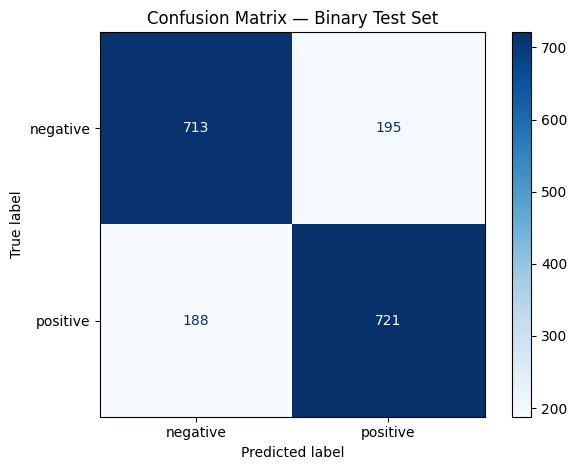

In [9]:
y_test_pred = model.predict(X_test_vec)

print(f'Test Accuracy (Binary): {accuracy_score(y_test, y_test_pred):.4f}\n')
print(classification_report(y_test, y_test_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test, y_test_pred, labels=['negative', 'positive'])
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Binary Test Set')
plt.tight_layout()
plt.show()

## 10. Top Discriminative Features (Binary Classification)

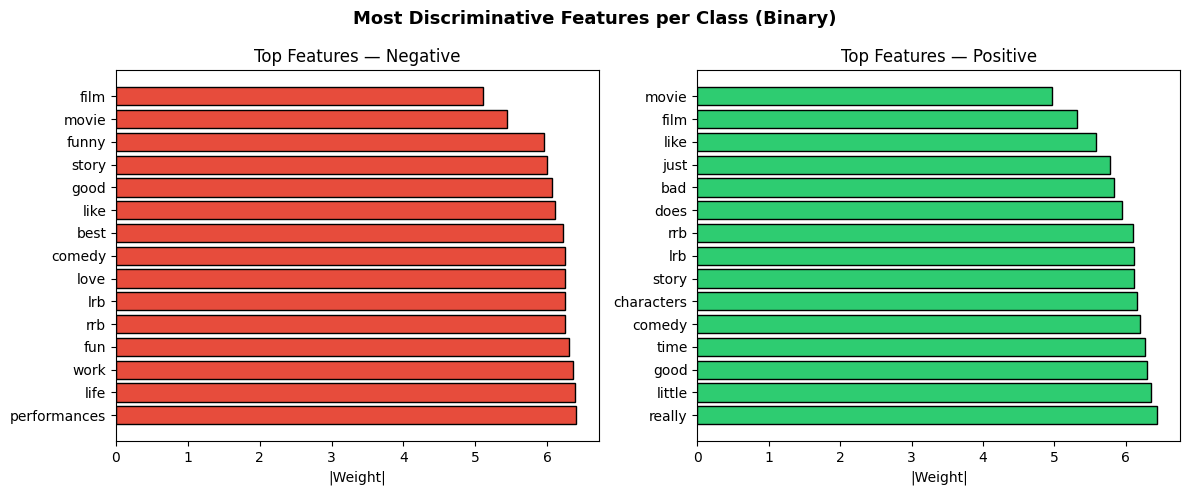

In [10]:
def top_features(model, vectorizer, class_label, n=15):
    class_idx = list(model.classes_).index(class_label)
    weights   = model.feature_log_prob_[class_idx]
    top_idx   = np.argsort(weights)[:n]  # lowest = most discriminative for ComplementNB
    features  = np.array(vectorizer.get_feature_names_out())
    return list(zip(features[top_idx], weights[top_idx]))

classes = list(model.classes_)
colors  = {'negative': '#e74c3c', 'positive': '#2ecc71'}

fig, axes = plt.subplots(1, len(classes), figsize=(12, 5))
for ax, cls in zip(axes, classes):
    feats = top_features(model, vectorizer, cls, n=15)
    words, scores = zip(*feats)
    ax.barh(words[::-1], np.abs(scores[::-1]), color=colors[cls], edgecolor='black')
    ax.set_title(f'Top Features — {cls.capitalize()}')
    ax.set_xlabel('|Weight|')

plt.suptitle('Most Discriminative Features per Class (Binary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Build 3-Class Model for Comparison (Optional)

Compare binary classification performance against 3-class model with neutral samples included.

In [11]:
# Build 3-class model using all data (including neutral) for comparison
df_3class = df.copy()

train_3class = df_3class[df_3class['split_set'] == 1]
test_3class  = df_3class[df_3class['split_set'] == 2]

vec_3class = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_3class = vec_3class.fit_transform(train_3class['sentence'])
X_test_3class = vec_3class.transform(test_3class['sentence'])

model_3class = ComplementNB(alpha=0.3)
model_3class.fit(X_train_3class, train_3class['label'])

y_pred_3class = model_3class.predict(X_test_3class)
accuracy_3class = accuracy_score(test_3class['label'], y_pred_3class)

print('=' * 60)
print('COMPARISON: Binary vs 3-Class')
print('=' * 60)
print(f'Binary Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}')
print(f'3-Class Test Accuracy: {accuracy_3class:.4f}')
print()
print('3-Class Classification Report:')
print(classification_report(test_3class['label'], y_pred_3class, target_names=['negative', 'neutral', 'positive']))


COMPARISON: Binary vs 3-Class
Binary Test Accuracy:  0.7892
3-Class Test Accuracy: 0.6235

3-Class Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.68      0.68       908
     neutral       0.26      0.18      0.22       390
    positive       0.68      0.75      0.71       909

    accuracy                           0.62      2207
   macro avg       0.54      0.54      0.54      2207
weighted avg       0.60      0.62      0.61      2207



## 12. Predict on Custom Sentences

In [12]:
custom_sentences = [
    "This film was an absolute masterpiece, I loved every second.",
    "Painfully boring and a complete waste of time.",
    "A refreshingly original story with superb performances.",
    "One of the worst movies I've ever watched.",
    "Brilliant acting and a compelling narrative.",
    "Watchable but uninspiring filmmaking.",
    "This is how a sentence without direct markers is classified."
]

custom_vec  = vectorizer.transform(custom_sentences)
predictions = model.predict(custom_vec)
proba       = model.predict_proba(custom_vec)

results = pd.DataFrame({'Sentence': custom_sentences, 'Predicted': predictions})
for cls in model.classes_:
    results[f'P({cls})'] = proba[:, list(model.classes_).index(cls)].round(3)

results

,Sentence,Predicted,P(negative),P(positive)
0,"This film was an absolute masterpiece, I loved...",positive,0.227,0.773
1,Painfully boring and a complete waste of time.,negative,0.933,0.067
2,A refreshingly original story with superb perf...,positive,0.069,0.931
3,One of the worst movies I've ever watched.,negative,0.915,0.085
4,Brilliant acting and a compelling narrative.,positive,0.204,0.796
5,Watchable but uninspiring filmmaking.,positive,0.240,0.760
6,This is how a sentence without direct markers ...,negative,0.868,0.132
